In [1]:
import arviz as az
import bambi as bmb
import numpy as np
import polars as pl

from matplotlib import pyplot as plt

In [2]:
TOP_VALUE = 34

In [3]:
msts = pl.read_csv("../data/prepared/biochem.csv").filter(variable="blood_glucose")
msts

rat,age,gtyp,sex,stage,variable,value
str,str,str,str,str,str,f64
"""20241011a""","""Adult""","""fa/+""","""F""","""beforeAnesthesia""","""blood_glucose""",6.4
"""20241011a""","""Adult""","""fa/+""","""F""","""vehicle""","""blood_glucose""",14.9
"""20241011a""","""Adult""","""fa/+""","""F""","""empa""","""blood_glucose""",14.0
"""20241011b""","""Adult""","""fa/+""","""F""","""vehicle""","""blood_glucose""",14.5
"""20241011b""","""Adult""","""fa/+""","""F""","""empa""","""blood_glucose""",11.0
…,…,…,…,…,…,…
"""20240823a""","""Young""","""fa/fa""","""F""","""empa""","""blood_glucose""",29.5
"""20240823b""","""Young""","""fa/fa""","""F""","""beforeAnesthesia""","""blood_glucose""",14.7
"""20240823b""","""Young""","""fa/fa""","""F""","""vehicle""","""blood_glucose""",21.6


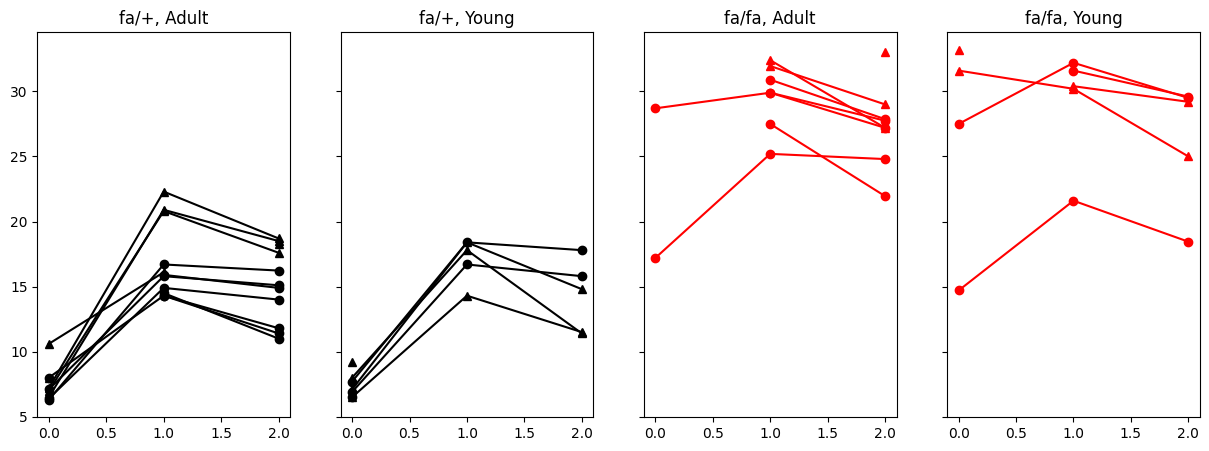

In [4]:
f, axes = plt.subplots(1, 4, sharey=True, figsize=[15, 5])
for ax, ((gtyp, age), subdf) in zip(
    axes, 
    msts.sort("gtyp", "age").group_by("gtyp", "age", maintain_order=True)
):
    for row in subdf.pivot(on="stage", values="value").rows(named=True):
        marker = "^" if row["sex"] == "M" else "o"
        color = "black" if row["gtyp"] == "fa/+" else "red"
        ax.plot(
            [row["beforeAnesthesia"], row["vehicle"], row["empa"]],
            marker=marker, 
            color=color
        )
        ax.set_title(f"{gtyp}, {age}")
    

In [5]:
all_msts = (
    pl.DataFrame({"rat": msts["rat"].unique(), "beforeAnesthesia": 1, "vehicle": 2, "empa": 3})
    .unpivot(index="rat", variable_name="stage", value_name="order")
    .sort("rat", "order")
    .join(msts[["rat", "age", "gtyp", "sex"]].unique(), on="rat", how="left")
    .drop("order")
)
all_msts

rat,stage,age,gtyp,sex
str,str,str,str,str
"""20240814a""","""beforeAnesthesia""","""Young""","""fa/fa""","""M"""
"""20240814a""","""vehicle""","""Young""","""fa/fa""","""M"""
"""20240814a""","""empa""","""Young""","""fa/fa""","""M"""
"""20240815a""","""beforeAnesthesia""","""Young""","""fa/+""","""F"""
"""20240815a""","""vehicle""","""Young""","""fa/+""","""F"""
…,…,…,…,…
"""20241030a""","""vehicle""","""Adult""","""fa/fa""","""F"""
"""20241030a""","""empa""","""Adult""","""fa/fa""","""F"""
"""20241030b""","""beforeAnesthesia""","""Adult""","""fa/fa""","""F"""


In [6]:
formula = "censored(log_value, too_high) ~ (0 + gtyp|rat) + stage + gtyp + sex + stage:gtyp + stage:sex"

filter_missing_measurements = ~(
    pl.col("value").is_null() & 
    ((pl.col("gtyp") == "fa/+") | (pl.col("rat") == "20240816a"))
)
model_df = (
    msts[["rat", "stage", "value"]]
    .join(all_msts, on=("rat", "stage"), how="right")
    .filter(filter_missing_measurements)
    .with_columns(
        too_high=pl.when(pl.col("value").is_null()).then(pl.lit("right")).otherwise(pl.lit("none")),
        value=pl.when(pl.col("value").is_null()).then(TOP_VALUE).otherwise(pl.col("value")),
    )
    .with_columns(log_value=np.log(pl.col("value")))
)
model_df
priors = {
    "gtyp|rat": bmb.Prior("Normal", mu=0.0, sigma=bmb.Prior("HalfNormal", sigma=[2.0, 2.0])),
    "stage": bmb.Prior("Normal", mu=0.0, sigma=2.0),
    "stage:gtyp": bmb.Prior("Normal", mu=0.0, sigma=2.0),
    "stage:sex": bmb.Prior("Normal", mu=0.0, sigma=2.0),
    "gtyp": bmb.Prior("Normal", mu=0.0, sigma=2.0),
    "sex": bmb.Prior("Normal", mu=0.0, sigma=2.0),

    
}

model = bmb.Model(formula=formula, data=model_df.to_pandas(), priors=priors)
model

       Formula: censored(log_value, too_high) ~ (0 + gtyp|rat) + stage + gtyp + sex + stage:gtyp + stage:sex
        Family: gaussian
          Link: mu = identity
  Observations: 90
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 1.5126, sigma: 3.6477)
            stage ~ Normal(mu: 0.0, sigma: 2.0)
            gtyp ~ Normal(mu: 0.0, sigma: 2.0)
            sex ~ Normal(mu: 0.0, sigma: 2.0)
            stage:gtyp ~ Normal(mu: 0.0, sigma: 2.0)
            stage:sex ~ Normal(mu: 0.0, sigma: 2.0)
        
        Group-level effects
            gtyp|rat ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: [2. 2.]))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 1.4591)

In [7]:
idata = model.fit(tune=3000, target_accept_prob=0.99,idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, stage, gtyp, sex, stage:gtyp, stage:sex, gtyp|rat_sigma, gtyp|rat_offset]


Output()

Sampling 4 chains for 3_000 tune and 1_000 draw iterations (12_000 + 4_000 draws total) took 3 seconds.


In [8]:
az.summary(idata, var_names=["~gtyp|rat", "~exp_mu", "~mu"])

/Users/tedgro/repos/teddygroves/kidney/.venv/lib/python3.13/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['exp_mu', 'mu'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.148,0.016,0.119,0.178,0.000,0.000,2051.0,2387.0,1.0
Intercept,1.897,0.057,1.789,2.005,0.001,0.001,2019.0,2621.0,1.0
stage[empa],0.740,0.068,0.614,0.869,0.001,0.001,2078.0,2704.0,1.0
stage[vehicle],0.858,0.068,0.726,0.977,0.001,0.001,2106.0,2712.0,1.0
gtyp[fa/fa],1.488,0.078,1.343,1.637,0.002,0.001,1783.0,2100.0,1.0
sex[M],0.169,0.070,0.032,0.295,0.001,0.001,2191.0,2471.0,1.0
"stage:gtyp[empa, fa/fa]",-0.865,0.083,-1.024,-0.712,0.002,0.001,2795.0,2752.0,1.0
"stage:gtyp[vehicle, fa/fa]",-0.887,0.082,-1.034,-0.734,0.002,0.001,2623.0,2741.0,1.0
"stage:sex[empa, M]",-0.054,0.082,-0.204,0.102,0.002,0.001,2735.0,2727.0,1.0
"stage:sex[vehicle, M]",-0.008,0.083,-0.157,0.155,0.002,0.001,2667.0,2208.0,1.0


In [9]:
idata = model.predict(idata, data=model_df, inplace=False, kind="response_params")
idata = model.predict(idata, data=model_df, inplace=False, kind="response")
idata.posterior["exp_mu"] = np.exp(idata.posterior["mu"])

[Text(0.5, 0, 'ln(model prediction)'), Text(0, 0.5, 'ln(measurement)')]

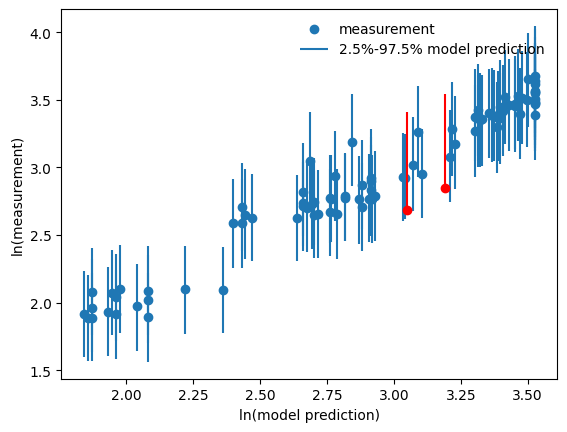

In [10]:
model_df=model_df.with_columns(
    low=idata.posterior_predictive["censored(log_value, too_high)"].quantile(0.025, dim=["chain", "draw"]).to_numpy(),
    med=idata.posterior_predictive["censored(log_value, too_high)"].quantile(0.5, dim=["chain", "draw"]).to_numpy(),
    high=idata.posterior_predictive["censored(log_value, too_high)"].quantile(0.975, dim=["chain", "draw"]).to_numpy(),
)
bad_prediction = (pl.col("log_value") > pl.col("high")) | (pl.col("log_value") < pl.col("low"))

f, ax = plt.subplots()
ax.scatter(model_df["log_value"], model_df["med"], label="measurement")
ax.vlines(model_df["log_value"], model_df["low"], model_df["high"], zorder=-1, label="2.5%-97.5% model prediction")

bad = model_df.filter(bad_prediction)
ax.scatter(bad["med"], bad["log_value"], color="red")
ax.vlines(bad["med"], bad["low"], bad["high"], color="red")

ax.legend(frameon=False);
ax.set(xlabel="ln(model prediction)", ylabel="ln(measurement)")

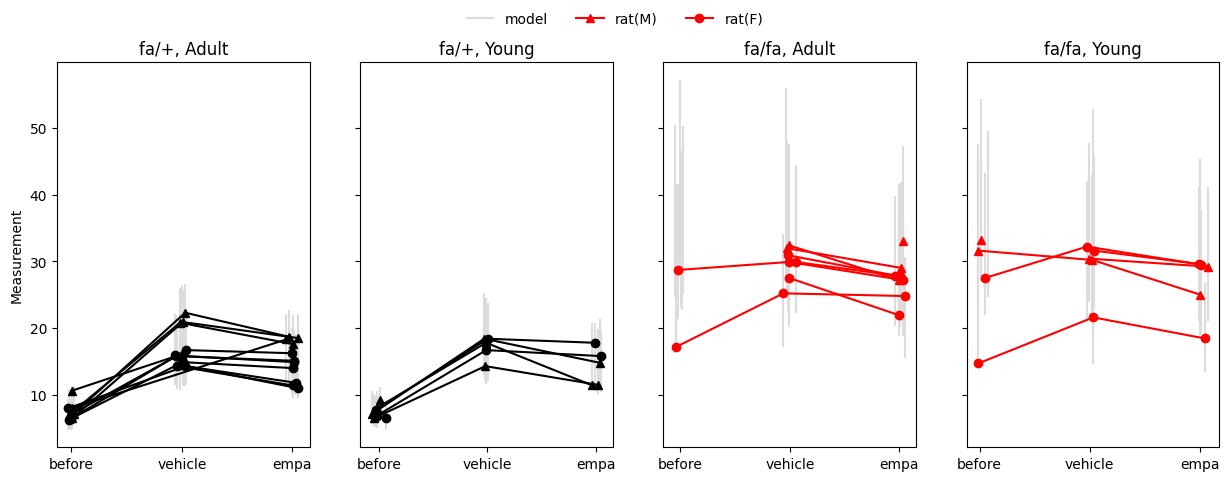

In [11]:
stage_order = {"beforeAnesthesia": 0, "vehicle": 1, "empa": 2}
f, axes = plt.subplots(1, 4, sharey=True, figsize=[15, 5])
plot_lines = {}
for ax, ((gtyp, age), subdf) in zip(
    axes, 
    model_df.with_columns(stage_order=pl.col("stage").replace(stage_order)).sort("gtyp", "age", "stage_order").group_by("gtyp", "age", maintain_order=True)
):
    for (rat,), subsubdf in subdf.sort("stage_order").group_by("rat"):
        jitter = np.random.normal(size=len(subsubdf), scale=0.03)
        marker = "^" if subsubdf["sex"][0] == "M" else "o"
        color = "black" if subsubdf["gtyp"][0] == "fa/+" else "red"
        x = [stage_order[stage] for stage in subsubdf["stage"]]
        plot_lines[subsubdf["sex"][0]] = ax.plot(x + jitter, subsubdf["value"].replace(TOP_VALUE, np.nan), marker=marker, color=color)
        vlines = ax.vlines(x + jitter, np.exp(subsubdf["low"]), np.exp(subsubdf["high"]), color="gainsboro", zorder=-1)
    ax.set_title(f"{gtyp}, {age}")
    ax.set_xticks([0, 1, 2], ["before", "vehicle", "empa"])
axes[0].set_ylabel("Measurement");
f.legend([vlines, plot_lines["M"][0], plot_lines["F"][0]], ["model", "rat(M)", "rat(F)"], frameon=False, ncol=3, loc="upper center");